# 10 — Modern Pipeline Evaluation, Calibration, and Uncertainty Examples

This notebook evaluates the EfficientNet-B0 model trained in notebook 09.

It produces:

- ROC/AUC;
- confusion matrices for MAP threshold 0.5 and cost-sensitive threshold 1/6;
- reliability diagrams and ECE;
- temperature scaling fitted on validation logits only;
- uncertainty/failure examples for qualitative discussion.


In [1]:
import os
import sys
from pathlib import Path

# Robust project discovery: supports both
#   parent/skin_lesion/src/config.py
# and
#   project/src/config.py
_cwd = Path(os.getcwd()).resolve()
SRC_DIR = None
PROJECT_DIR = None
for _root in [_cwd, *_cwd.parents]:
    cand = _root / "skin_lesion" / "src" / "config.py"
    if cand.exists():
        SRC_DIR = cand.parent
        PROJECT_DIR = SRC_DIR.parent
        break
    cand = _root / "src" / "config.py"
    if cand.exists():
        SRC_DIR = cand.parent
        PROJECT_DIR = SRC_DIR.parent
        break

if SRC_DIR is None:
    raise FileNotFoundError(
        "Could not find src/config.py. Run this notebook from inside the project "
        "or from the parent folder containing skin_lesion/."
    )

sys.path.insert(0, str(SRC_DIR))

from config import SEED, COST_FN, COST_FP, MC_DROPOUT_T

# Use paths relative to the detected project folder. This avoids path issues
# if the zip is extracted either as skin_lesion/ or as the project root.
RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "results" / "figures"
TABLES_DIR = PROJECT_DIR / "results" / "tables"
MODELS_DIR = PROJECT_DIR / "results" / "models"

for d in [PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_DIR   : {PROJECT_DIR}")
print(f"RAW_DIR       : {RAW_DIR}")
print(f"PROCESSED_DIR : {PROCESSED_DIR}")
print(f"FIGURES_DIR   : {FIGURES_DIR}")
print(f"TABLES_DIR    : {TABLES_DIR}")
print(f"MODELS_DIR    : {MODELS_DIR}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.optimize import minimize_scalar

from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    log_loss,
)


PROJECT_DIR   : C:\Users\tella\Projects\skin_lesion_triage\skin_lesion
RAW_DIR       : C:\Users\tella\Projects\skin_lesion_triage\skin_lesion\data\raw
PROCESSED_DIR : C:\Users\tella\Projects\skin_lesion_triage\skin_lesion\data\processed
FIGURES_DIR   : C:\Users\tella\Projects\skin_lesion_triage\skin_lesion\results\figures
TABLES_DIR    : C:\Users\tella\Projects\skin_lesion_triage\skin_lesion\results\tables
MODELS_DIR    : C:\Users\tella\Projects\skin_lesion_triage\skin_lesion\results\models


## 1 — Load EfficientNet predictions


In [2]:
val_path = PROCESSED_DIR / "efficientnet_predictions_val.csv"
test_path = PROCESSED_DIR / "efficientnet_predictions_test.csv"

if not val_path.exists() or not test_path.exists():
    raise FileNotFoundError(
        "Missing EfficientNet predictions. Run 09_efficientnet_training.ipynb first."
    )

val_pred = pd.read_csv(val_path)
test_pred = pd.read_csv(test_path)

for df in [val_pred, test_pred]:
    df["image_id"] = df["image_id"].astype(str)
    df["label"] = df["label"].astype(int)

print(f"Validation predictions: {val_pred.shape}")
print(f"Test predictions      : {test_pred.shape}")
print(test_pred.head())


Validation predictions: (441, 5)
Test predictions      : (451, 5)
       image_id split  label     logit  prob_melanoma
0  ISIC_0026993  test      1  3.459400       0.969510
1  ISIC_0026120  test      1  2.905649       0.948125
2  ISIC_0028412  test      1  3.129250       0.958083
3  ISIC_0026531  test      1  2.034274       0.884349
4  ISIC_0032396  test      1  2.034176       0.884339


## 2 — Metrics helpers


In [3]:
THRESH_MAP = 0.5
THRESH_COST = COST_FP / (COST_FP + COST_FN)  # = 1/6 when FN=5 and FP=1
N_BINS = 15

print(f"MAP threshold            : {THRESH_MAP:.6f}")
print(f"Cost-sensitive threshold : {THRESH_COST:.6f}")


def binary_metrics(labels, probs, threshold, model="efficientnet_b0", calibration="none"):
    labels = np.asarray(labels).astype(int)
    probs = np.asarray(probs).astype(float)
    pred = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, pred, labels=[0, 1]).ravel()
    return {
        "model": model,
        "calibration": calibration,
        "threshold": threshold,
        "accuracy": accuracy_score(labels, pred),
        "sensitivity": recall_score(labels, pred, pos_label=1, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "precision": precision_score(labels, pred, pos_label=1, zero_division=0),
        "f1": f1_score(labels, pred, pos_label=1, zero_division=0),
        "FN": int(fn),
        "FP": int(fp),
        "TP": int(tp),
        "TN": int(tn),
        "total_cost": int(COST_FN * fn + COST_FP * fp),
    }


def reliability_stats(probs, labels, n_bins=15):
    labels = np.asarray(labels).astype(int)
    probs = np.asarray(probs).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    bin_conf = np.full(n_bins, np.nan)
    bin_acc = np.full(n_bins, np.nan)
    bin_counts = np.zeros(n_bins, dtype=int)
    for m in range(n_bins):
        mask = (probs >= bins[m]) & (probs < bins[m + 1])
        if m == n_bins - 1:
            mask |= probs == bins[m + 1]
        if mask.sum() > 0:
            bin_conf[m] = probs[mask].mean()
            bin_acc[m] = labels[mask].mean()
            bin_counts[m] = mask.sum()
    return centers, bin_conf, bin_acc, bin_counts


def expected_calibration_error(probs, labels, n_bins=15):
    _, bin_conf, bin_acc, bin_counts = reliability_stats(probs, labels, n_bins)
    valid = ~np.isnan(bin_conf)
    n = len(labels)
    return float(np.sum((bin_counts[valid] / n) * np.abs(bin_acc[valid] - bin_conf[valid])))


def plot_reliability(ax, probs, labels, title, n_bins=15):
    centers, bin_conf, bin_acc, bin_counts = reliability_stats(probs, labels, n_bins)
    valid = ~np.isnan(bin_conf)
    width = 1.0 / n_bins * 0.85
    ax.bar(centers[valid], bin_acc[valid], width=width, alpha=0.7, label="Fraction positives")
    ax.plot([0, 1], [0, 1], "--", lw=1.5, label="Perfect")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction positives")
    ax.set_title(f"{title}\nECE = {expected_calibration_error(probs, labels, n_bins):.4f}")
    ax.grid(True, linestyle=":")
    ax.legend(fontsize=8)


MAP threshold            : 0.500000
Cost-sensitive threshold : 0.166667


## 3 — ROC curve and raw-threshold decisions


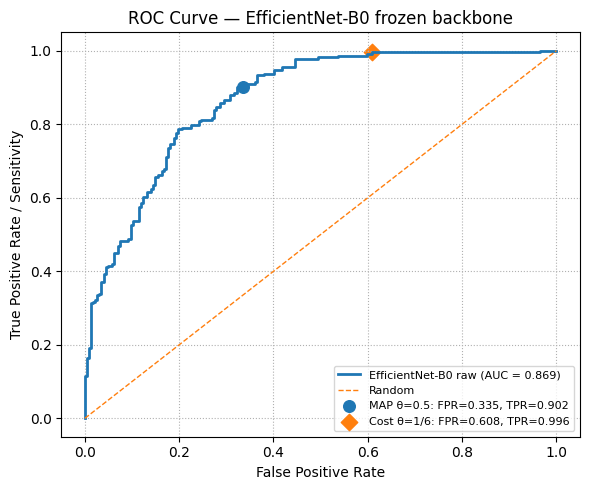

Raw EfficientNet test AUC = 0.8692
          model calibration  threshold  accuracy  sensitivity  specificity  precision       f1  FN  FP  TP  TN  total_cost
efficientnet_b0        none   0.500000  0.787140     0.901786     0.674009   0.731884 0.808000  22  74 202 153         184
efficientnet_b0        none   0.166667  0.689579     0.995536     0.387665   0.616022 0.761092   1 139 223  88         144


In [4]:
y_test = test_pred["label"].to_numpy(dtype=int)
probs_raw = test_pred["prob_melanoma"].to_numpy(dtype=float)
logits_test = test_pred["logit"].to_numpy(dtype=float)

fpr, tpr, roc_thresholds = roc_curve(y_test, probs_raw)
auc_raw = roc_auc_score(y_test, probs_raw)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, label=f"EfficientNet-B0 raw (AUC = {auc_raw:.3f})")
ax.plot([0, 1], [0, 1], "--", lw=1, label="Random")
for th, name, marker in [(THRESH_MAP, "MAP θ=0.5", "o"), (THRESH_COST, "Cost θ=1/6", "D")]:
    idx = np.argmin(np.abs(roc_thresholds - th))
    ax.scatter(fpr[idx], tpr[idx], s=70, marker=marker, label=f"{name}: FPR={fpr[idx]:.3f}, TPR={tpr[idx]:.3f}")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate / Sensitivity")
ax.set_title("ROC Curve — EfficientNet-B0 frozen backbone")
ax.grid(True, linestyle=":")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "modern_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Raw EfficientNet test AUC = {auc_raw:.4f}")

rows_raw = [
    binary_metrics(y_test, probs_raw, THRESH_MAP,  calibration="none"),
    binary_metrics(y_test, probs_raw, THRESH_COST, calibration="none"),
]
raw_decisions = pd.DataFrame(rows_raw)
print(raw_decisions.to_string(index=False))


## 4 — Raw calibration: reliability diagram and ECE


ECE raw EfficientNet = 0.0737


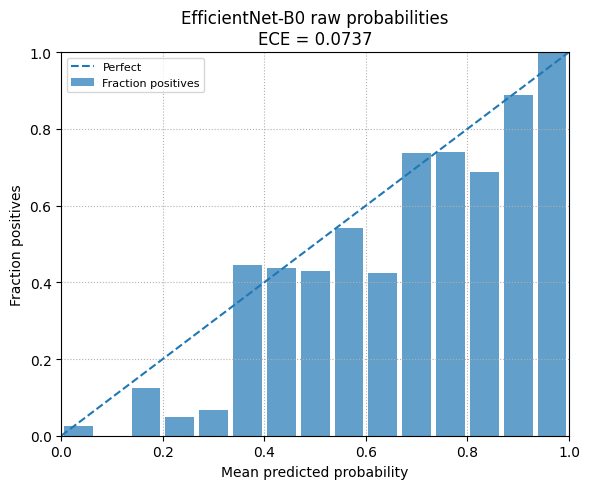

In [5]:
ece_raw = expected_calibration_error(probs_raw, y_test, N_BINS)
print(f"ECE raw EfficientNet = {ece_raw:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
plot_reliability(ax, probs_raw, y_test, "EfficientNet-B0 raw probabilities", N_BINS)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "modern_reliability_raw.png", dpi=150, bbox_inches="tight")
plt.show()


## 5 — Temperature scaling

Temperature is fitted on **validation logits only**. The test set is used only after `T` has been selected.


In [6]:
y_val = val_pred["label"].to_numpy(dtype=int)
logits_val = val_pred["logit"].to_numpy(dtype=float)


def sigmoid_stable(z):
    z = np.asarray(z, dtype=float)
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


def nll_temperature(T, logits, labels):
    probs = sigmoid_stable(logits / T)
    eps = 1e-15
    probs = np.clip(probs, eps, 1 - eps)
    return -np.mean(labels * np.log(probs) + (1 - labels) * np.log(1 - probs))

result = minimize_scalar(
    nll_temperature,
    args=(logits_val, y_val),
    bounds=(0.05, 20.0),
    method="bounded",
)
T_opt = float(result.x)
print(f"Optimal temperature T = {T_opt:.4f}")
print(f"Validation NLL before scaling: {nll_temperature(1.0, logits_val, y_val):.4f}")
print(f"Validation NLL after scaling : {nll_temperature(T_opt, logits_val, y_val):.4f}")

probs_cal = sigmoid_stable(logits_test / T_opt)
ece_cal = expected_calibration_error(probs_cal, y_test, N_BINS)
auc_cal = roc_auc_score(y_test, probs_cal)

print(f"Test AUC raw/calibrated: {auc_raw:.4f} / {auc_cal:.4f}")
print(f"Test ECE raw/calibrated: {ece_raw:.4f} / {ece_cal:.4f}")


Optimal temperature T = 0.9367
Validation NLL before scaling: 0.4552
Validation NLL after scaling : 0.4547
Test AUC raw/calibrated: 0.8692 / 0.8692
Test ECE raw/calibrated: 0.0737 / 0.0754


## 6 — Calibrated reliability and decision table


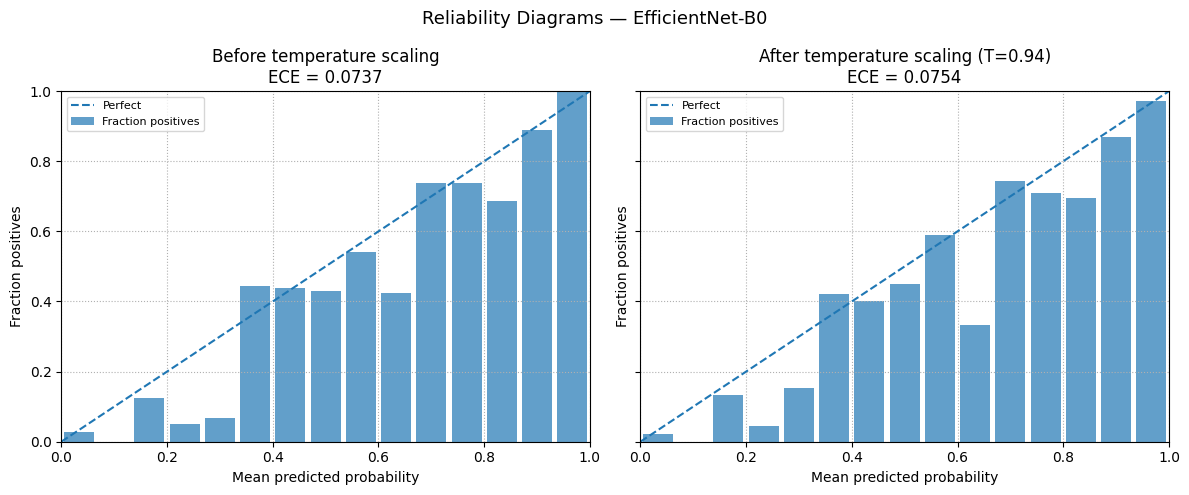

          model         calibration  threshold  accuracy  sensitivity  specificity  precision     f1  FN  FP  TP  TN  total_cost
efficientnet_b0                none   0.500000    0.7871       0.9018       0.6740     0.7319 0.8080  22  74 202 153         184
efficientnet_b0                none   0.166667    0.6896       0.9955       0.3877     0.6160 0.7611   1 139 223  88         144
efficientnet_b0 temperature_scaling   0.500000    0.7871       0.9018       0.6740     0.7319 0.8080  22  74 202 153         184
efficientnet_b0 temperature_scaling   0.166667    0.6896       0.9911       0.3921     0.6167 0.7603   2 138 222  89         148
Saved: C:\Users\tella\Projects\skin_lesion_triage\skin_lesion\results\tables\efficientnet_decision_comparison.csv
          model         calibration      T    auc    ece  n_bins
efficientnet_b0                none 1.0000 0.8692 0.0737      15
efficientnet_b0 temperature_scaling 0.9367 0.8692 0.0754      15
Saved: C:\Users\tella\Projects\skin_lesion_tri

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
plot_reliability(axes[0], probs_raw, y_test, "Before temperature scaling", N_BINS)
plot_reliability(axes[1], probs_cal, y_test, f"After temperature scaling (T={T_opt:.2f})", N_BINS)
fig.suptitle("Reliability Diagrams — EfficientNet-B0", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "modern_reliability_calibrated.png", dpi=150, bbox_inches="tight")
plt.show()

rows = []
for calibration, probs in [("none", probs_raw), ("temperature_scaling", probs_cal)]:
    rows.append(binary_metrics(y_test, probs, THRESH_MAP, calibration=calibration))
    rows.append(binary_metrics(y_test, probs, THRESH_COST, calibration=calibration))

decision_df = pd.DataFrame(rows)
for col in ["accuracy", "sensitivity", "specificity", "precision", "f1"]:
    decision_df[col] = decision_df[col].round(4)
decision_df["threshold"] = decision_df["threshold"].round(6)
print(decision_df.to_string(index=False))

out_dec = TABLES_DIR / "efficientnet_decision_comparison.csv"
decision_df.to_csv(out_dec, index=False)
print(f"Saved: {out_dec}")

cal_df = pd.DataFrame([
    {"model": "efficientnet_b0", "calibration": "none", "T": 1.0, "auc": auc_raw, "ece": ece_raw, "n_bins": N_BINS},
    {"model": "efficientnet_b0", "calibration": "temperature_scaling", "T": T_opt, "auc": auc_cal, "ece": ece_cal, "n_bins": N_BINS},
])
cal_df[["auc", "ece", "T"]] = cal_df[["auc", "ece", "T"]].round(4)
print(cal_df.to_string(index=False))
out_cal = TABLES_DIR / "efficientnet_calibration_summary.csv"
cal_df.to_csv(out_cal, index=False)
print(f"Saved: {out_cal}")

# Save calibrated test predictions.
test_pred_cal = test_pred.copy()
test_pred_cal["prob_melanoma_calibrated"] = probs_cal
test_pred_cal["temperature"] = T_opt
test_pred_cal.to_csv(PROCESSED_DIR / "efficientnet_predictions_test_calibrated.csv", index=False)
print(f"Saved: {PROCESSED_DIR / 'efficientnet_predictions_test_calibrated.csv'}")


## 7 — Confusion matrices


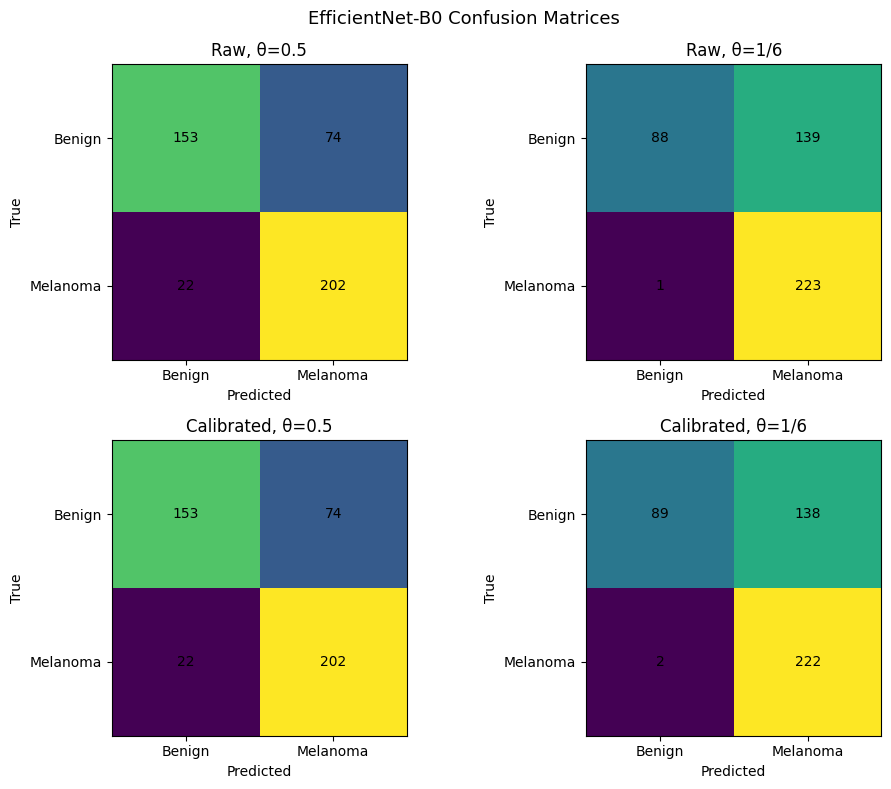

In [8]:
def plot_confusion(ax, labels, probs, threshold, title):
    pred = (probs >= threshold).astype(int)
    cm = confusion_matrix(labels, pred, labels=[0, 1])
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1], ["Benign", "Melanoma"])
    ax.set_yticks([0, 1], ["Benign", "Melanoma"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    return im

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
plot_confusion(axes[0, 0], y_test, probs_raw, THRESH_MAP,  "Raw, θ=0.5")
plot_confusion(axes[0, 1], y_test, probs_raw, THRESH_COST, "Raw, θ=1/6")
plot_confusion(axes[1, 0], y_test, probs_cal, THRESH_MAP,  "Calibrated, θ=0.5")
plot_confusion(axes[1, 1], y_test, probs_cal, THRESH_COST, "Calibrated, θ=1/6")
fig.suptitle("EfficientNet-B0 Confusion Matrices", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "modern_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## 8 — Qualitative uncertainty and failure examples

We show examples useful for the report:

1. confident correct melanoma;
2. confident correct benign;
3. false negative if present;
4. false positive if present;
5. probability near 0.5;
6. probability near the cost-sensitive threshold 1/6.


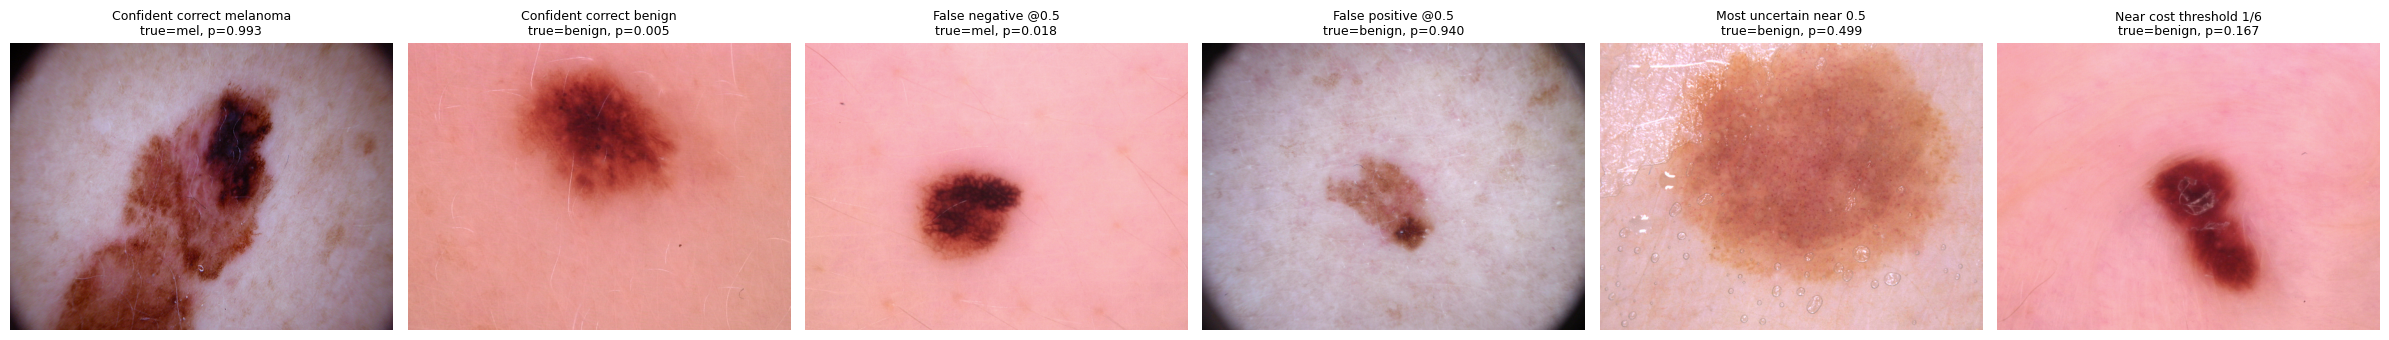

              example_type     image_id  true_label  prob_melanoma_calibrated  pred_05  pred_cost
Confident correct melanoma ISIC_0033479           1                  0.993158        1          1
  Confident correct benign ISIC_0026533           0                  0.005147        0          0
       False negative @0.5 ISIC_0028760           1                  0.017974        0          0
       False positive @0.5 ISIC_0033363           0                  0.940294        1          1
   Most uncertain near 0.5 ISIC_0031654           0                  0.499130        0          1
   Near cost threshold 1/6 ISIC_0024888           0                  0.166805        0          1
Saved examples table to: C:\Users\tella\Projects\skin_lesion_triage\skin_lesion\results\tables\efficientnet_uncertainty_examples.csv


In [9]:
subset_path = PROCESSED_DIR / "balanced_subset.csv"
subset = pd.read_csv(subset_path)
subset["image_id"] = subset["image_id"].astype(str)

# Fallback path resolution as in notebook 09.
image_index = {p.stem: p for p in RAW_DIR.rglob("*.jpg")}
def resolve_path(row):
    p = row.get("image_path", None)
    if isinstance(p, str) and Path(p).exists():
        return p
    q = image_index.get(str(row["image_id"]))
    return str(q) if q is not None else None

subset["image_path_resolved"] = subset.apply(resolve_path, axis=1)
examples_df = test_pred_cal.merge(
    subset[["image_id", "image_path_resolved"]], on="image_id", how="left"
)
examples_df["p"] = examples_df["prob_melanoma_calibrated"]
examples_df["pred_05"] = (examples_df["p"] >= THRESH_MAP).astype(int)
examples_df["pred_cost"] = (examples_df["p"] >= THRESH_COST).astype(int)

selections = []

def add_example(name, df, sort_col=None, ascending=False):
    if len(df) == 0:
        print(f"No candidate for: {name}")
        return
    if sort_col is not None:
        row = df.sort_values(sort_col, ascending=ascending).iloc[0]
    else:
        row = df.iloc[0]
    selections.append((name, row))

add_example(
    "Confident correct melanoma",
    examples_df[(examples_df["label"] == 1) & (examples_df["pred_05"] == 1)],
    sort_col="p", ascending=False,
)
add_example(
    "Confident correct benign",
    examples_df[(examples_df["label"] == 0) & (examples_df["pred_05"] == 0)],
    sort_col="p", ascending=True,
)
add_example(
    "False negative @0.5",
    examples_df[(examples_df["label"] == 1) & (examples_df["pred_05"] == 0)],
    sort_col="p", ascending=True,
)
add_example(
    "False positive @0.5",
    examples_df[(examples_df["label"] == 0) & (examples_df["pred_05"] == 1)],
    sort_col="p", ascending=False,
)

near_05 = examples_df.assign(distance=(examples_df["p"] - THRESH_MAP).abs()).sort_values("distance")
add_example("Most uncertain near 0.5", near_05)

near_cost = examples_df.assign(distance=(examples_df["p"] - THRESH_COST).abs()).sort_values("distance")
add_example("Near cost threshold 1/6", near_cost)

n = len(selections)
fig, axes = plt.subplots(1, n, figsize=(4 * max(n, 1), 4))
if n == 1:
    axes = [axes]

for ax, (title, row) in zip(axes, selections):
    img_path = row["image_path_resolved"]
    if isinstance(img_path, str) and Path(img_path).exists():
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, "missing image", ha="center", va="center")
    true_name = "mel" if row["label"] == 1 else "benign"
    ax.set_title(f"{title}\ntrue={true_name}, p={row['p']:.3f}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "modern_uncertainty_examples.png", dpi=150, bbox_inches="tight")
plt.show()

examples_table = pd.DataFrame([
    {
        "example_type": name,
        "image_id": row["image_id"],
        "true_label": int(row["label"]),
        "prob_melanoma_calibrated": float(row["p"]),
        "pred_05": int(row["pred_05"]),
        "pred_cost": int(row["pred_cost"]),
    }
    for name, row in selections
])
examples_table.to_csv(TABLES_DIR / "efficientnet_uncertainty_examples.csv", index=False)
print(examples_table.to_string(index=False))
print(f"Saved examples table to: {TABLES_DIR / 'efficientnet_uncertainty_examples.csv'}")
